Bank Customer Churn Prediction using Machine Learning

Objective
The goal of this project is to predict whether a bank customer will leave (churn) or stay with the bank using machine learning classification algorithms.



1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

 2. Load the Dataset

In [ ]:
df = pd.read_csv("/content/Bank_Churn_Classification_Dataset.csv")

 3. Dataset Exploration

In [ ]:
df.head()

,Unnamed: 0,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


In [ ]:
df.shape

(10000, 10)

In [ ]:
df.columns

Index(['Unnamed: 0', 'CustomerID', 'Gender', 'SeniorCitizen', 'Tenure',
       'MonthlyCharges', 'Contract', 'PaymentMethod', 'Churn', 'TotalCharges'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10000 non-null  int64  
 1   CustomerID      10000 non-null  int64  
 2   Gender          10000 non-null  object 
 3   SeniorCitizen   10000 non-null  int64  
 4   Tenure          10000 non-null  int64  
 5   MonthlyCharges  10000 non-null  float64
 6   Contract        10000 non-null  object 
 7   PaymentMethod   10000 non-null  object 
 8   Churn           10000 non-null  int64  
 9   TotalCharges    10000 non-null  float64
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [ ]:
df.describe()

,Unnamed: 0,CustomerID,SeniorCitizen,Tenure,MonthlyCharges,Churn,TotalCharges
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,4999.50000,0.499300,35.955000,70.451038,0.267000,2541.807390
std,2886.89568,2886.89568,0.500025,20.501761,28.935692,0.442414,1879.645307
min,0.00000,0.00000,0.000000,1.000000,20.000000,0.000000,21.200000
25%,2499.75000,2499.75000,0.000000,18.000000,45.527500,0.000000,1035.057500
50%,4999.50000,4999.50000,0.000000,36.000000,70.585000,0.000000,2117.135000
75%,7499.25000,7499.25000,1.000000,54.000000,95.612500,1.000000,3717.352500
max,9999.00000,9999.00000,1.000000,71.000000,120.000000,1.000000,8384.390000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
CustomerID,0
Gender,0
SeniorCitizen,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
Churn,0
TotalCharges,0


In [ ]:
df.duplicated().sum()

np.int64(0)

 4. Data Cleaning

In [8]:
df1 = df.copy()

In [9]:
df1.head()

,Unnamed: 0,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


In [10]:
df1.drop("Unnamed: 0", axis=1, inplace=True)

In [11]:
df1.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Tenure', 'MonthlyCharges',
       'Contract', 'PaymentMethod', 'Churn', 'TotalCharges'],
      dtype='object')

In [12]:
df1.dtypes

,0
CustomerID,int64
Gender,object
SeniorCitizen,int64
Tenure,int64
MonthlyCharges,float64
Contract,object
PaymentMethod,object
Churn,int64
TotalCharges,float64


In [13]:
df1.isnull().sum()

,0
CustomerID,0
Gender,0
SeniorCitizen,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
Churn,0
TotalCharges,0


In [14]:
df1.duplicated().sum()

np.int64(0)

 5. Exploratory Data Analysis (EDA)

In [15]:
df1['Churn'].value_counts()

,count
Churn,
0,7330
1,2670


 5.1 Customer Churn Distribution

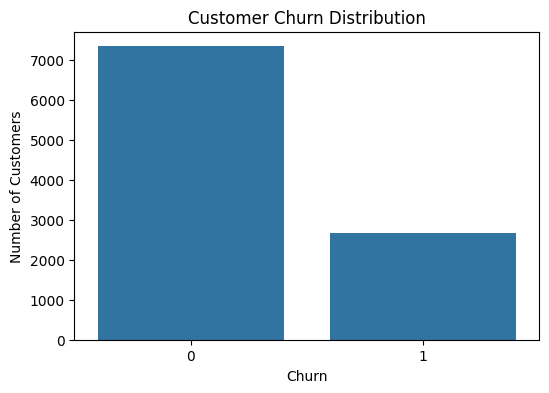

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df1)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig("Customer Churn Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

5.2 Gender vs Customer Churn

In [17]:
df1['Gender'].value_counts()

,count
Gender,
Male,5013
Female,4987


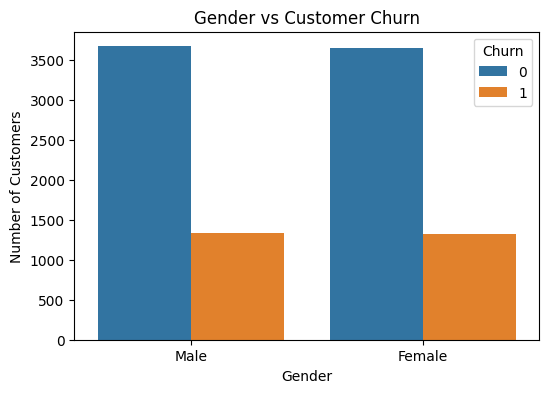

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', hue='Churn', data=df1)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.savefig("Gender vs Customer Churn.png", dpi=300, bbox_inches="tight")
plt.show()

 5.3 Senior Citizen vs Customer Churn

In [19]:
df1['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5007
1,4993


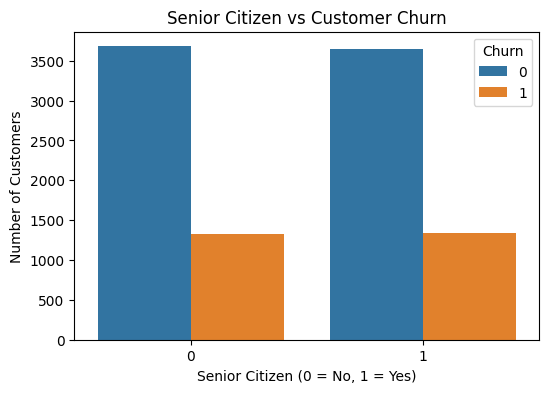

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x='SeniorCitizen', hue='Churn', data=df1)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.savefig("Senior Citizen vs Customer Churn.png", dpi=300, bbox_inches="tight")
plt.show()

5.4 Contract Type vs Customer Churn

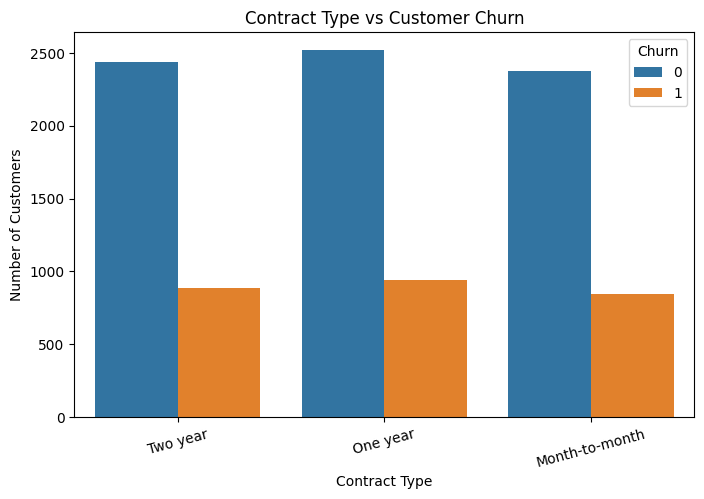

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df1)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.savefig("Contract Type vs Customer Churn.png", dpi=300, bbox_inches="tight")
plt.xticks(rotation=15)

plt.show()

 5.5 Payment Method vs Customer Churn

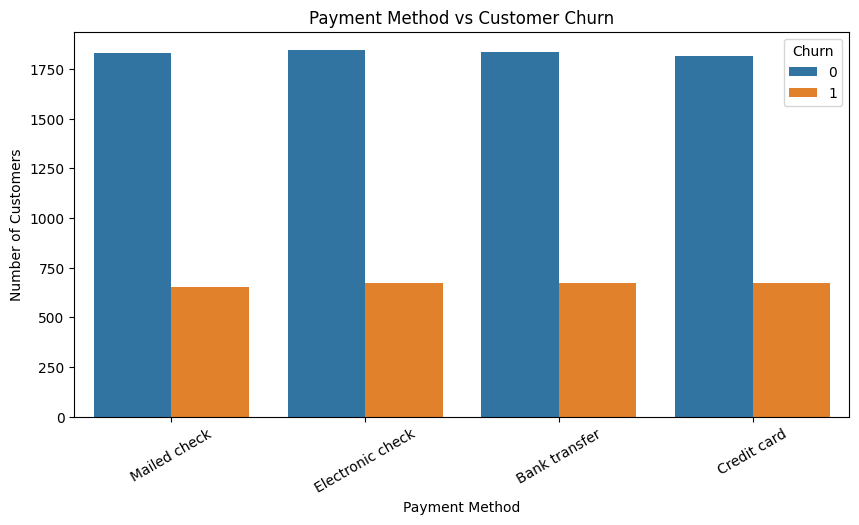

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(x='PaymentMethod', hue='Churn', data=df1)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.savefig("Payment Method vs Customer Churn.png", dpi=300, bbox_inches="tight")
plt.show()

5.6 Monthly Charges Distribution

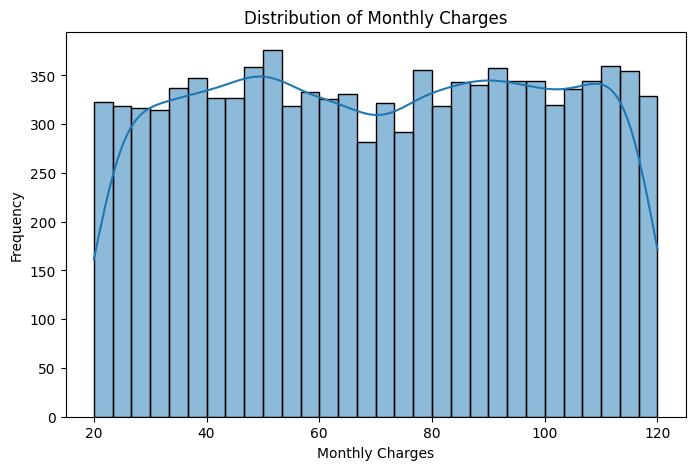

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df1['MonthlyCharges'], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.savefig("Distribution of Monthly Charges.png", dpi=300, bbox_inches="tight")
plt.show()

5.7 Customer Tenure Distribution

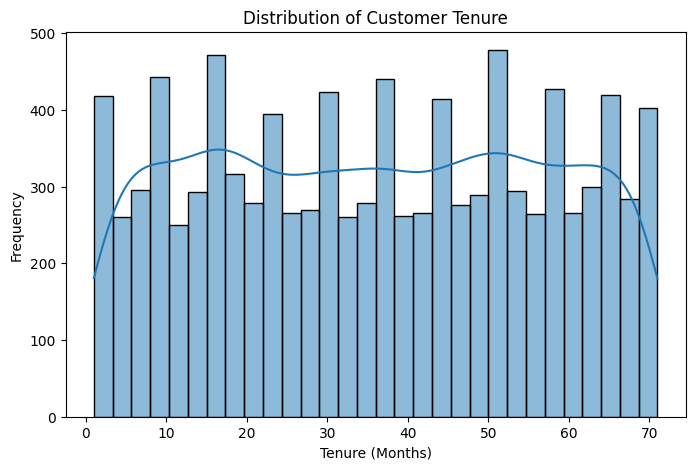

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df1['Tenure'], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.savefig("Distribution of Customer Tenure.png", dpi=300, bbox_inches="tight")
plt.show()

5.8 Correlation Heatmap

In [26]:
df_heatmap = df1.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_heatmap.select_dtypes(include='object').columns:
    df_heatmap[col] = le.fit_transform(df_heatmap[col])

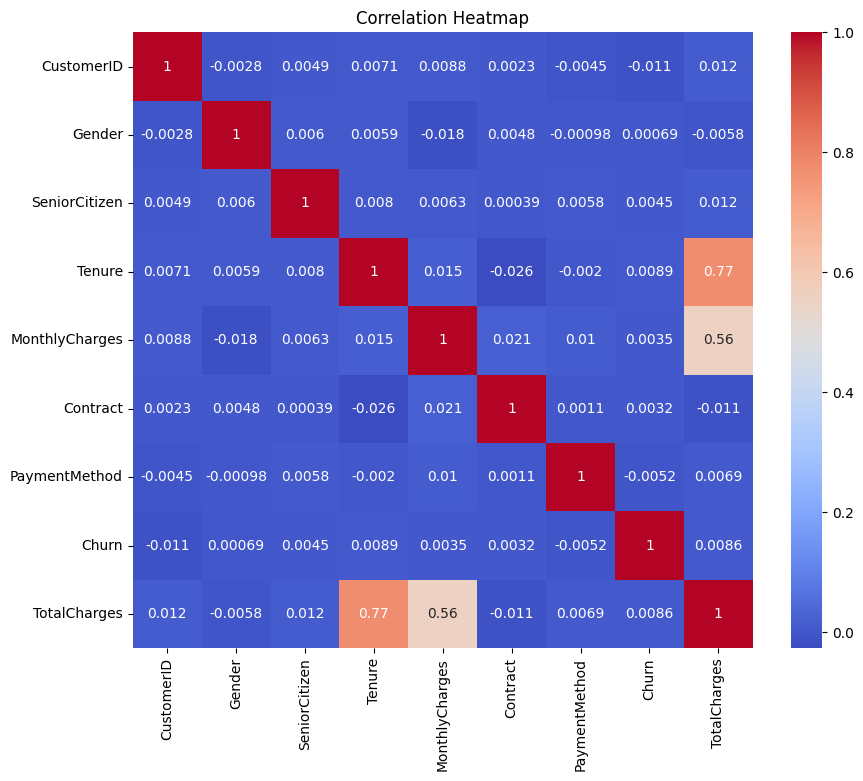

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(df_heatmap.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.savefig("Correlation Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

 6. Data Preprocessing

In [28]:
df1.dtypes

,0
CustomerID,int64
Gender,object
SeniorCitizen,int64
Tenure,int64
MonthlyCharges,float64
Contract,object
PaymentMethod,object
Churn,int64
TotalCharges,float64


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df1.select_dtypes(include='object').columns

for col in categorical_columns:
    df1[col] = le.fit_transform(df1[col])

In [30]:
df1.head()

,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,1,0,55,111.88,2,3,0,6153.40
1,1,0,1,36,58.70,2,2,0,2113.20
2,2,1,0,37,118.86,1,2,0,4397.82
3,3,1,1,14,96.14,0,3,1,1345.96
4,4,1,1,27,28.05,2,3,0,757.35


In [31]:
X = df1.drop("Churn", axis=1)
y = df1["Churn"]

In [32]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 8)
Target: (10000,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 8)
(2000, 8)
(8000,)
(2000,)


 7. Model Building
7.1 Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
model = LogisticRegression()

In [37]:
model.fit(X_train, y_train)

LogisticRegression()

In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.736


In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1472    0]
 [ 528    0]]


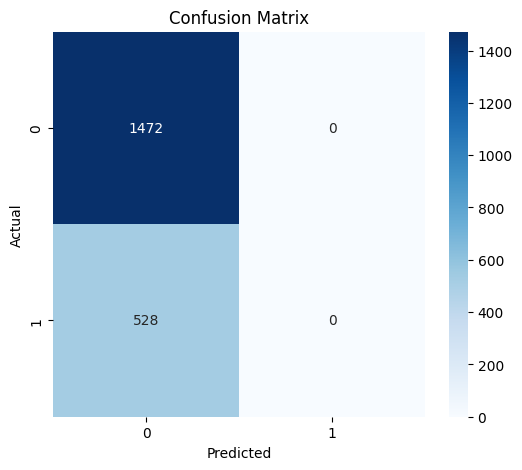

In [43]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Confusion Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1472
           1       0.00      0.00      0.00       528

    accuracy                           0.74      2000
   macro avg       0.37      0.50      0.42      2000
weighted avg       0.54      0.74      0.62      2000



In [45]:
lr_accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.736


7.2 Decision Tree Classifier

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
dt_model = DecisionTreeClassifier(random_state=42)

In [48]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [49]:
dt_pred = dt_model.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.614


 7.3 Random Forest Classifier

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [53]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [54]:
rf_pred = rf_model.predict(X_test)

In [55]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.726


 8. Model Comparison

In [56]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.736
1,Decision Tree,0.614
2,Random Forest,0.726


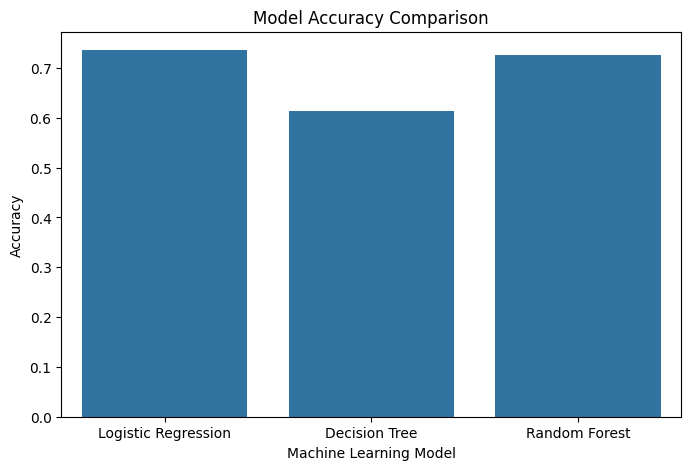

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.savefig("Model Accuracy Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Conclusion : This project successfully developed a machine learning model to predict customer churn. The workflow included data cleaning, exploratory data analysis, preprocessing, model training, and evaluation. Among the evaluated algorithms, the best-performing model was selected based on accuracy. This project demonstrates a complete end-to-end machine learning pipeline for solving a real-world business problem.